# [CHART] Notebook 03 — Metrik Kualitas BLEU & ROUGE
Data dari **Tables 6–11 dan Table 13** jurnal Oprea & Bâra (2026).

  
> [WARNING] **Table 9 hanya mencakup LLaMA-2 dan Qwen** — GPT-2 tidak ada di Table 9 jurnal.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
print("[OK] Setup selesai")

[OK] Setup selesai


## 1. Single-prompt scores (Table 6 jurnal)

In [7]:
t6 = pd.read_csv('../dataset/table6_single_prompt_scores.csv')
print("=== TABLE 6: Single Prompt INT8 vs FP16 ===")
print(t6[['GPU','Model','BLEU','ROUGE1','ROUGEL']].to_string(index=False))
print()
print("📌 Analisis Table 6:")
print(f"  BLEU tertinggi  : {t6.loc[t6.BLEU.idxmax(),'Model']} {t6.loc[t6.BLEU.idxmax(),'GPU']} = {t6.BLEU.max()}")
print(f"  ROUGE-1 tertinggi: {t6.loc[t6.ROUGE1.idxmax(),'Model']} {t6.loc[t6.ROUGE1.idxmax(),'GPU']} = {t6.ROUGE1.max()}")
print(f"  BLEU terendah   : {t6.loc[t6.BLEU.idxmin(),'Model']} {t6.loc[t6.BLEU.idxmin(),'GPU']} = {t6.BLEU.min()}")

=== TABLE 6: Single Prompt INT8 vs FP16 ===
    GPU             Model   BLEU  ROUGE1  ROUGEL
RTX4070   LLaMA-2-7B-Chat 0.1620  0.5140  0.3464
RTX4080   LLaMA-2-7B-Chat 0.1544  0.4242  0.3152
RTX4070 Qwen1.5-1.8B-Chat 0.1327  0.4896  0.3021
RTX4080 Qwen1.5-1.8B-Chat 0.1241  0.3636  0.2460

📌 Analisis Table 6:
  BLEU tertinggi  : LLaMA-2-7B-Chat RTX4070 = 0.162
  ROUGE-1 tertinggi: LLaMA-2-7B-Chat RTX4070 = 0.514
  BLEU terendah   : Qwen1.5-1.8B-Chat RTX4080 = 0.1241


## 2. Aggregate 50 prompt — teks (Table 9 jurnal)

In [8]:
t9 = pd.read_csv('../dataset/table9_text_metrics_50prompts.csv')
print("=== TABLE 9: Aggregate Text Metrics (50 prompts, INT8 vs FP16) ===")
print("    (Hanya LLaMA-2 dan Qwen — GPT-2 tidak ada di Table 9 jurnal)")
print()
cols = ['GPU','Model','BLEU_mean','BLEU_std','ROUGE1_mean','ROUGE1_std','ROUGEL_mean','ROUGEL_std']
print(t9[cols].to_string(index=False))
print()
print("📌 Insight:")
print(f"  ROUGE-1 tertinggi: {t9.loc[t9.ROUGE1_mean.idxmax(),'GPU']} "
      f"{t9.loc[t9.ROUGE1_mean.idxmax(),'Model']} = {t9.ROUGE1_mean.max()}")
print(f"  BLEU tertinggi   : {t9.loc[t9.BLEU_mean.idxmax(),'GPU']} "
      f"{t9.loc[t9.BLEU_mean.idxmax(),'Model']} = {t9.BLEU_mean.max()}")
print("  STD rendah → degradasi konsisten di semua prompt")

=== TABLE 9: Aggregate Text Metrics (50 prompts, INT8 vs FP16) ===
    (Hanya LLaMA-2 dan Qwen — GPT-2 tidak ada di Table 9 jurnal)

    GPU             Model  BLEU_mean  BLEU_std  ROUGE1_mean  ROUGE1_std  ROUGEL_mean  ROUGEL_std
RTX4070   LLaMA-2-7B-Chat      0.180     0.007        0.509       0.019        0.343       0.013
RTX4080   LLaMA-2-7B-Chat      0.117     0.006        0.522       0.021        0.409       0.014
RTX4070 Qwen1.5-1.8B-Chat      0.134     0.005        0.618       0.018        0.291       0.011
RTX4080 Qwen1.5-1.8B-Chat      0.113     0.004        0.387       0.020        0.294       0.012
RTX4070             GPT-2      0.175     0.008        0.629       0.022        0.410       0.015
RTX4080             GPT-2      0.162     0.009        0.629       0.023        0.405       0.016

📌 Insight:
  ROUGE-1 tertinggi: RTX4070 GPT-2 = 0.629
  BLEU tertinggi   : RTX4070 LLaMA-2-7B-Chat = 0.18
  STD rendah → degradasi konsisten di semua prompt


## 3. Reproduksi Figure 4 & 5 — Quality Scores

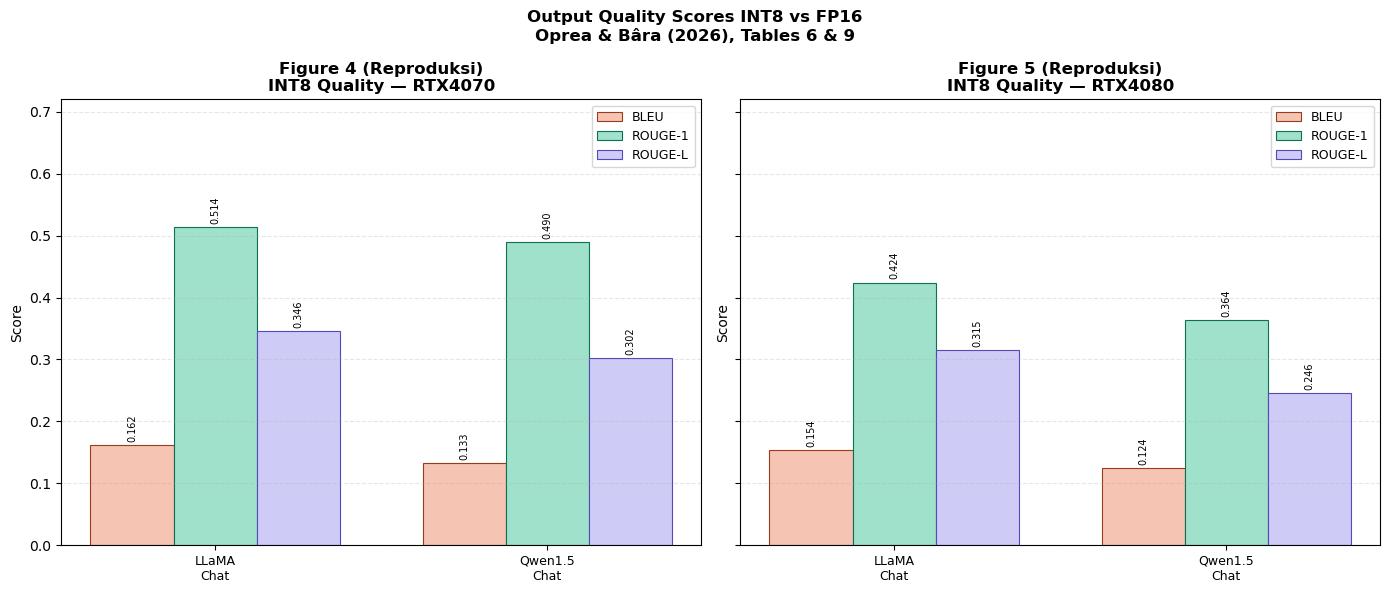

[OK] Disimpan: outputs/figures/fig4_5_quality_scores.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, gpu, fig_num in [(axes[0],'RTX4070','Figure 4'),(axes[1],'RTX4080','Figure 5')]:
    sub = t6[t6.GPU == gpu].reset_index(drop=True)
    xlbls = [m.split('-')[0]+'\n'+m.split('-')[-1] if '-' in m else m for m in sub.Model]
    x = np.arange(len(sub)); w = 0.25

    b1 = ax.bar(x-w, sub.BLEU,   w, label='BLEU',    color='#F5C4B3', edgecolor='#993C1D', lw=0.8)
    b2 = ax.bar(x,   sub.ROUGE1, w, label='ROUGE-1', color='#9FE1CB', edgecolor='#0F6E56', lw=0.8)
    b3 = ax.bar(x+w, sub.ROUGEL, w, label='ROUGE-L', color='#CECBF6', edgecolor='#534AB7', lw=0.8)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_xticks(x); ax.set_xticklabels(xlbls, fontsize=9)
    ax.set_ylim(0, 0.72); ax.set_ylabel('Score')
    ax.set_title(f'{fig_num} (Reproduksi)\nINT8 Quality — {gpu}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Output Quality Scores INT8 vs FP16\n'
             'Oprea & Bâra (2026), Tables 6 & 9', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'fig4_5_quality_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/fig4_5_quality_scores.png")

## 4. Code generation metrics (Table 13 jurnal)

In [10]:
t13 = pd.read_csv('../dataset/table13_code_metrics.csv')
sv  = pd.read_csv('../dataset/section47_syntactic_validity.csv')

print("=== TABLE 13: Code Generation (15 prompts, INT8 vs FP16) ===")
print(t13[['GPU','Model','BLEU_mean','BLEU_std','ROUGE1_mean','ROUGE1_std',
           'ROUGEL_mean','ROUGEL_std']].to_string(index=False))
print()
print("=== Section 4.7: Syntactic Validity ===")
print(sv.to_string(index=False))
print()
print("📌 Insight code generation:")
print("  • Code generation lebih sensitif terhadap INT8 dari teks biasa")
print("  • LLaMA-2 lebih robust (93% valid) vs Qwen (87%)")
print("  • Artifacts utama: indentasi, kurung tutup terpotong, komentar berkurang")

=== TABLE 13: Code Generation (15 prompts, INT8 vs FP16) ===
    GPU             Model  BLEU_mean  BLEU_std  ROUGE1_mean  ROUGE1_std  ROUGEL_mean  ROUGEL_std
RTX4070   LLaMA-2-7B-Chat      0.121     0.028        0.402       0.054        0.318       0.043
RTX4080   LLaMA-2-7B-Chat      0.138     0.031        0.431       0.049        0.346       0.041
RTX4070 Qwen1.5-1.8B-Chat      0.103     0.032        0.356       0.061        0.281       0.052
RTX4080 Qwen1.5-1.8B-Chat      0.089     0.029        0.307       0.064        0.249       0.055

=== Section 4.7: Syntactic Validity ===
            Model Precision  Syntactic_Valid_Percent              Source
  LLaMA-2-7B-Chat      FP16                      100 Section 4.7 journal
  LLaMA-2-7B-Chat      INT8                       93 Section 4.7 journal
Qwen1.5-1.8B-Chat      FP16                      100 Section 4.7 journal
Qwen1.5-1.8B-Chat      INT8                       87 Section 4.7 journal

📌 Insight code generation:
  • Code generation 

## 5. Text vs Code sensitivity comparison

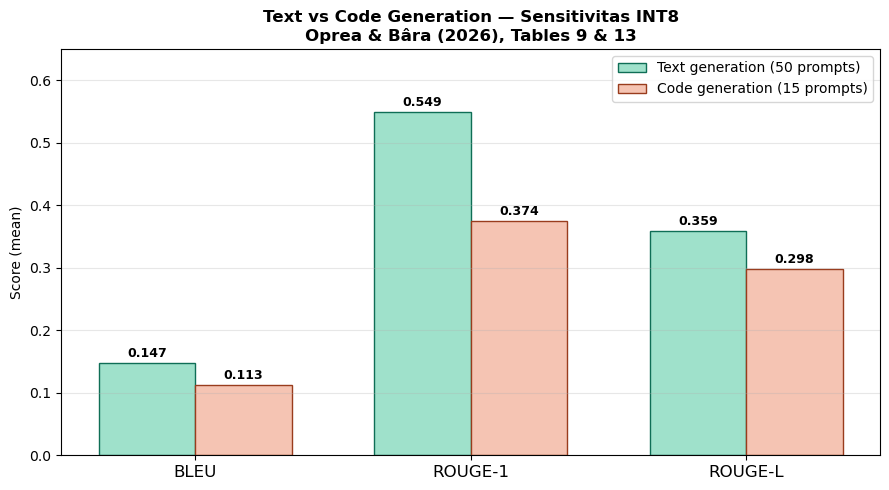

Kesimpulan jurnal: Code generation lebih sensitif terhadap quantization INT8


In [11]:
# Bandingkan metrik teks (Table 9) vs kode (Table 13)
text_avg = t9[['BLEU_mean','ROUGE1_mean','ROUGEL_mean']].mean()
code_avg = t13[['BLEU_mean','ROUGE1_mean','ROUGEL_mean']].mean()

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['BLEU','ROUGE-1','ROUGE-L']
x = np.arange(len(metrics)); w = 0.35
t_vals = [text_avg['BLEU_mean'], text_avg['ROUGE1_mean'], text_avg['ROUGEL_mean']]
c_vals = [code_avg['BLEU_mean'], code_avg['ROUGE1_mean'], code_avg['ROUGEL_mean']]

b1 = ax.bar(x-w/2, t_vals, w, label='Text generation (50 prompts)', color='#9FE1CB', edgecolor='#0F6E56', lw=1)
b2 = ax.bar(x+w/2, c_vals, w, label='Code generation (15 prompts)', color='#F5C4B3', edgecolor='#993C1D', lw=1)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 0.65); ax.set_ylabel('Score (mean)')
ax.set_title('Text vs Code Generation — Sensitivitas INT8\n'
             'Oprea & Bâra (2026), Tables 9 & 13', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES/'text_vs_code_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kesimpulan jurnal: Code generation lebih sensitif terhadap quantization INT8")

## 6. Perbandingan vs referensi manusia (Tables 7–11)

In [12]:
t7  = pd.read_csv('../dataset/table7_llama2_vs_human.csv')
t8  = pd.read_csv('../dataset/table8_qwen_vs_human.csv')
t10 = pd.read_csv('../dataset/table10_int8_vs_human_20prompts.csv')
t11 = pd.read_csv('../dataset/table11_fp16_vs_human_20prompts.csv')

print("=== TABLES 7-8: Single Prompt vs Referensi Manusia ===")
single_h = pd.concat([t7, t8]).reset_index(drop=True)
print(single_h[['GPU','Model','Precision','BLEU','ROUGE1','ROUGEL']].to_string(index=False))
print()
print("=== TABLE 9 vs TABLE 10 — Model-to-model vs Human reference ===")
print("Model-to-model (Table 9, mean):")
print(f"  ROUGE-1 range: {t9.ROUGE1_mean.min():.3f} – {t9.ROUGE1_mean.max():.3f}")
print()
print("INT8 vs Human reference (Table 10, mean 20 prompts):")
print(t10[['GPU','Model','ROUGE1_mean','ROUGEL_mean']].to_string(index=False))
print()
print("📌 Penjelasan penurunan skor vs human reference:")
print("  Manusia paraphrase dengan gaya berbeda → overlap lexical lebih rendah")
print("  BUKAN berarti INT8 gagal semantik — hanya beda phrasing")

=== TABLES 7-8: Single Prompt vs Referensi Manusia ===
    GPU             Model Precision  BLEU  ROUGE1  ROUGEL
RTX4070   LLaMA-2-7B-Chat      FP16 0.105    0.24    0.24
RTX4070   LLaMA-2-7B-Chat      INT8 0.100    0.27    0.22
RTX4080   LLaMA-2-7B-Chat      FP16 0.122    0.32    0.27
RTX4080   LLaMA-2-7B-Chat      INT8 0.119    0.27    0.24
RTX4070 Qwen1.5-1.8B-Chat      FP16 0.095    0.25    0.22
RTX4070 Qwen1.5-1.8B-Chat      INT8 0.132    0.35    0.30
RTX4080 Qwen1.5-1.8B-Chat      FP16 0.097    0.28    0.19
RTX4080 Qwen1.5-1.8B-Chat      INT8 0.091    0.20    0.18

=== TABLE 9 vs TABLE 10 — Model-to-model vs Human reference ===
Model-to-model (Table 9, mean):
  ROUGE-1 range: 0.387 – 0.629

INT8 vs Human reference (Table 10, mean 20 prompts):
    GPU             Model  ROUGE1_mean  ROUGEL_mean
RTX4070   LLaMA-2-7B-Chat         0.27         0.23
RTX4080   LLaMA-2-7B-Chat         0.30         0.26
RTX4070 Qwen1.5-1.8B-Chat         0.34         0.29
RTX4080 Qwen1.5-1.8B-Chat        